# Perform data cleaning and explotary data analysis (EDA) on a dataset of your choice , such as the titanic dataset from kaggle. Explore the relationship between variable and identify patterns and trends in the data,

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("datasets/test.csv")

# Data Cleaning

In [31]:
#Age: Fill using median grouped by Pclass + Sex
df['Age'] = df.groupby(['Pclass','Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

#Fare: Fill using median grouped by Pclass
df['Fare'] = df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

#Embarked: Fill with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

#Cabin: Create HasCabin and drop Cabin
df['HasCabin'] = df['Cabin'].notnull().astype(int)
df.drop(columns=['Cabin'], inplace=True)


# Feature Engineering

In [32]:
#Family Size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

#IsAlone
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

#IsFemale
df['IsFemale'] = (df['Sex'] == 'female').astype(int)

#Age Binning
df['AgeBin'] = pd.cut(df['Age'],
                     bins=[0,12,18,35,60,100],
                     labels=['Child','Teen','YoungAdult','Adult','Senior'])

# Basic Information

In [33]:
print("\nMissing Values After Cleaning:\n", df.isnull().sum())
print("\nSummary:\n", df.describe())


Missing Values After Cleaning:
 PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
FamilySize     0
IsAlone        0
IsFemale       0
AgeBin         0
dtype: int64

Summary:
        PassengerId      Pclass         Age       SibSp       Parch  \
count   418.000000  418.000000  418.000000  418.000000  418.000000   
mean   1100.500000    2.265550   29.297847    0.447368    0.392344   
std     120.810458    0.841838   13.038856    0.896760    0.981429   
min     892.000000    1.000000    0.170000    0.000000    0.000000   
25%     996.250000    1.000000   22.000000    0.000000    0.000000   
50%    1100.500000    3.000000   25.000000    0.000000    0.000000   
75%    1204.750000    3.000000   36.375000    1.000000    0.000000   
max    1309.000000    3.000000   76.000000    8.000000    9.000000   

             Fare    HasCabin  FamilySize     IsAlone    

# EDA Visualizations

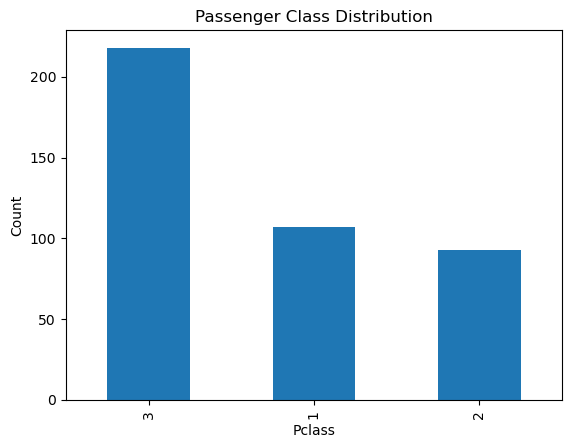

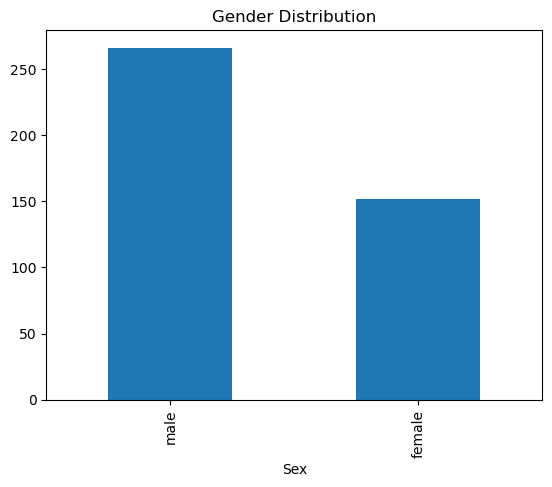

<Figure size 640x480 with 0 Axes>

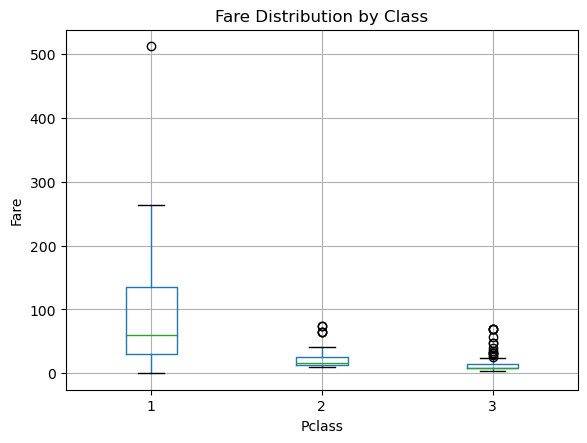

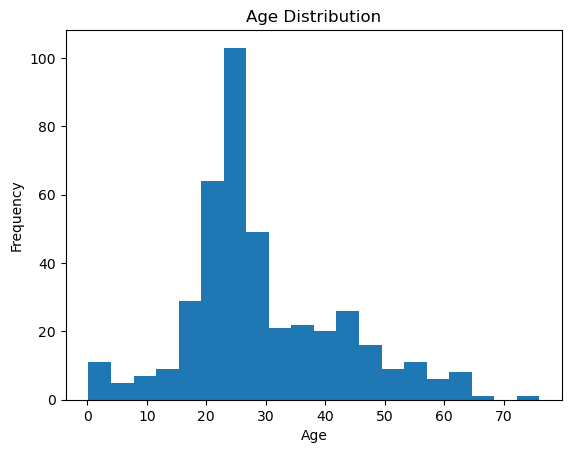

<Figure size 640x480 with 0 Axes>

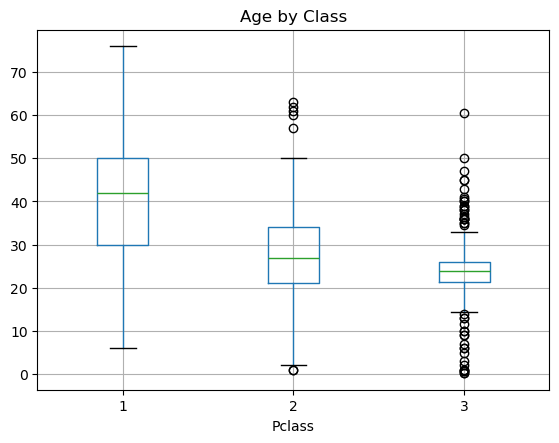

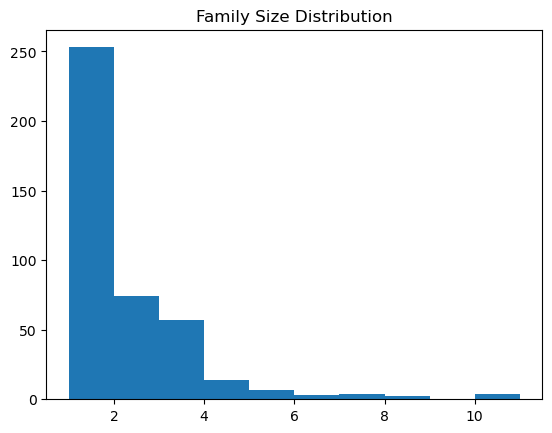

<Figure size 640x480 with 0 Axes>

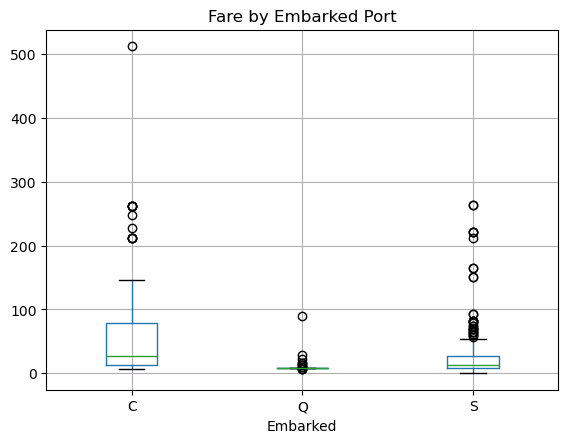

In [34]:
#Pclass Distribution
plt.figure()
df['Pclass'].value_counts().plot(kind='bar')
plt.title("Passenger Class Distribution")
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.show()

#Gender Distribution
plt.figure()
df['Sex'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.show()

#Fare by Class (Box Plot)
plt.figure()
df.boxplot(column='Fare', by='Pclass')
plt.title("Fare Distribution by Class")
plt.suptitle("")
plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.show()

#Age Distribution
plt.figure()
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#Age by Class
plt.figure()
df.boxplot(column='Age', by='Pclass')
plt.title("Age by Class")
plt.suptitle("")
plt.show()

#Family Size Distribution
plt.figure()
plt.hist(df['FamilySize'], bins=10)
plt.title("Family Size Distribution")
plt.show()

#Embarked vs Fare
plt.figure()
df.boxplot(column='Fare', by='Embarked')
plt.title("Fare by Embarked Port")
plt.suptitle("")
plt.show()

# Correlation Analysis


Correlation Matrix:
              PassengerId    Pclass       Age     SibSp     Parch      Fare  \
PassengerId     1.000000 -0.026751 -0.042871  0.003818  0.043080  0.008764   
Pclass         -0.026751  1.000000 -0.534379  0.001087  0.018721 -0.577488   
Age            -0.042871 -0.534379  1.000000 -0.080162 -0.058455  0.348014   
SibSp           0.003818  0.001087 -0.080162  1.000000  0.306895  0.172031   
Parch           0.043080  0.018721 -0.058455  0.306895  1.000000  0.230409   
Fare            0.008764 -0.577488  0.348014  0.172031  0.230409  1.000000   
HasCabin        0.006462 -0.690579  0.393670  0.073067  0.037237  0.561118   
FamilySize      0.030087  0.012736 -0.085088  0.788610  0.827242  0.250417   
IsAlone        -0.000629  0.173555 -0.030575 -0.618483 -0.495618 -0.283147   
IsFemale       -0.023245 -0.108615 -0.007134  0.099943  0.159120  0.192225   

             HasCabin  FamilySize   IsAlone  IsFemale  
PassengerId  0.006462    0.030087 -0.000629 -0.023245  
Pclass 

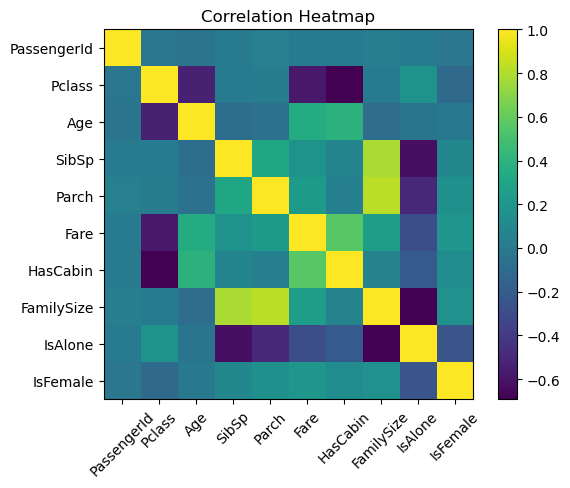

In [35]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
corr = df[numeric_cols].corr()

print("\nCorrelation Matrix:\n", corr)

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.show()

# Key Relationships

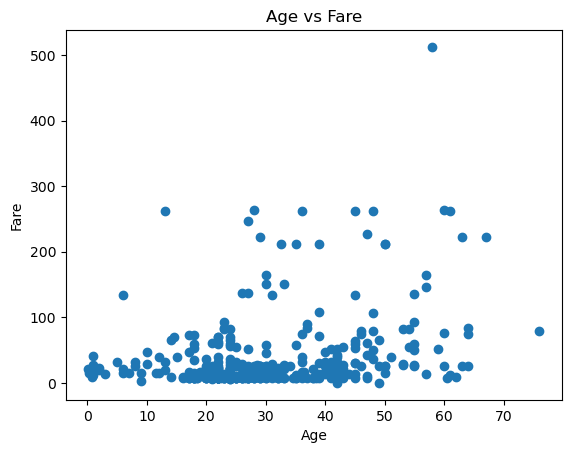

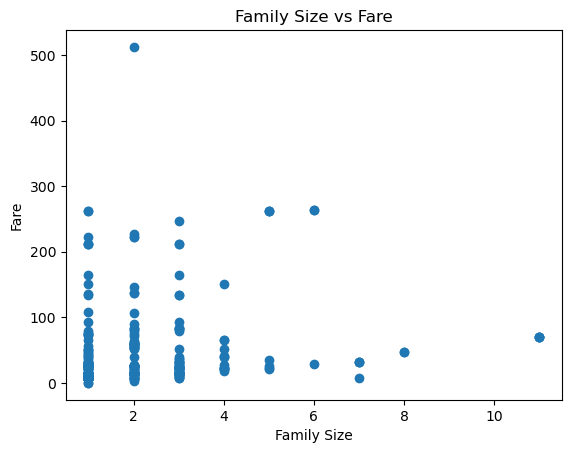


EDA + Feature Engineering Completed ✅


In [36]:
# Age vs Fare
plt.figure()
plt.scatter(df['Age'], df['Fare'])
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

# FamilySize vs Fare
plt.figure()
plt.scatter(df['FamilySize'], df['Fare'])
plt.title("Family Size vs Fare")
plt.xlabel("Family Size")
plt.ylabel("Fare")
plt.show()

print("\nEDA + Feature Engineering Completed ✅")